Class-based workflow for waste resonance zoom, waste baseline, and pump-power/DC-bias scans.


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

WINDOWS_LIB_PATHS = [
    r"C:\\_Lib\\python\\slab\\instruments",
    r"C:\\_Lib\\python",
    r"C:\\_Lib\\python\\InstrumentControl\\Devices\\basel",
    r"C:\\_Lib\\python\\InstrumentControl",
    r"C:\\_Lib\\python\\InstrumentControl\\Devices\\RF_switch",
    r"C:\\_Lib\\python\\slab_qick_calib\\analysis",
]

for lib_path in WINDOWS_LIB_PATHS:
    if lib_path not in sys.path:
        sys.path.append(lib_path)

import fitres
from SMPD_VNA import (
    FitResAdapter,
    PumpBiasScan,
    PowerScanAcquisition,
    PowerScanAnalyzer,
    RFSwitchChannelSurvey,
    SMPDVNA,
    VNASweepConfig,
    WasteBaseline,
    WasteResonanceZoom,
    load_pump_bias_scan_result,
    load_power_scan_result,
    NoiseReadoutStudy,
    load_sweep_result,
    plot_gain_heatmap,
)

%matplotlib inline



# Hardware Setup


In [2]:
import RhodeSchwarz
import basel
import RC2SP4TA18 as RF_switch
from SignalCore import SignalCore

VNA_ADDRESS = "192.168.137.84"
RF_SWITCH_HOST = "192.168.137.131"
BFG_RF_SWITCH_HOST = "192.168.137.132"
SIGNALCORE_ADDRESS = "100026C4"
BASEL_CHANNEL = 12
JPA_OFF_BIAS_MV = 0
JPA_ON_BIAS_MV = 26.37
JPA_PUMP_POWER_DBM = -9.3
JPA_PUMP_FREQUENCY_HZ = 7740e6

RS = RhodeSchwarz.ZVB8(address=VNA_ADDRESS)
print(RS.get_id())

bias = basel.Basel(allowed_range_mv=15000)
bias.set_voltage_mV(BASEL_CHANNEL, voltage_mv=0)
bias.enable_output(BASEL_CHANNEL)

vna = SMPDVNA(RS, clear_output_func=clear_output, sleep_s=0.1)
fit_adapter = FitResAdapter(
    fitres,
    fit_type="reflection",
    hpd=True,
    phase_first=True,
)

waste_zoom = WasteResonanceZoom(vna, fit_adapter)
baseline_runner = WasteBaseline(vna)
power_scan_acquisition = PowerScanAcquisition(vna)


Could not load InstrumentManagerWindow
Could not import QickInstrument, try install qick package
Could not load labbrick
Could not load Autonics TM4 Driver
I'm Bat Mouse!
Rohde-Schwarz,ZNB26-4Port,1334333065100972,3.45

Connection OK
 to IP: ('192.168.137.217', 23)
Received: 0



In [3]:
# RF switch 192.168.137.131
# Run 28 config: 
#   - <A0>:  A13| <Acom>: VNA3| <A1>: <Dcom>|
#   - <B0>: <C0>| <Bcom>:   C9| <B1>:   Qick|
#   - <C0>: <B0>| <Ccom>: VNA4| <C1>:    C11|
#   - <D0>:   A9| <Dcom>: <A1>| <D1>:     B1|
# for JPA gain measurement with VNA: A1, B0, C0, D0
# for qick measurement: B1
# RF switch state used for JPA gain measurement with VNA.
switch = RF_switch.RC2SP4TA18Controller(host=RF_SWITCH_HOST)
switch.connect()

#switch.switch("A", 0)
switch.switch("A", 1)

switch.switch("B", 0)
#switch.switch("B", 1)


switch.switch("C", 0)
#switch.switch("C", 1)

switch.switch("D", 0)
#switch.switch("D", 1)

switch.disconnect()


Connected to 192.168.137.131:23
Response: 1
Response: 1
Response: 1
Response: 1
Disconnected from the device.


# JPA On/Off


## Turn JPA Off


In [3]:
VOLTAGE_MV = JPA_OFF_BIAS_MV

bias.set_voltage_mV(BASEL_CHANNEL, voltage_mv=VOLTAGE_MV)
bias.enable_output(BASEL_CHANNEL)

SC = SignalCore(name="SC", address=SIGNALCORE_ADDRESS)
params = SC.get_rf_parameters()
print(params.rf1_freq, params.rf_level)

SC.set_output_state(enable=False)
status = SC.get_device_status()
print(status.operate_status.rf1_out_enable)

SC.close_device()


7740000000 -9.84000015258789
SC100026C4 : Set output state to False
SC100026C4 : Successfully obtained device status
0


0

## Turn JPA On


In [25]:
SC.close_device()


OSError: exception: access violation reading 0x0000000000000040

In [27]:
JPA_ON_BIAS_MV = 30.60
JPA_PUMP_POWER_DBM = -9.84
JPA_PUMP_FREQUENCY_HZ = 7740e6

VOLTAGE_MV = JPA_ON_BIAS_MV
POWER_DBM = JPA_PUMP_POWER_DBM
FREQ_HZ = JPA_PUMP_FREQUENCY_HZ

bias.set_voltage_mV(BASEL_CHANNEL, voltage_mv=VOLTAGE_MV)
bias.enable_output(BASEL_CHANNEL)

SC = SignalCore(name="SC", address=SIGNALCORE_ADDRESS)
SC.set_power(POWER_DBM)
SC.set_output_state(enable=True)
SC.set_frequency(FREQ_HZ)

params = SC.get_rf_parameters()
status = SC.get_device_status()
print(params.rf1_freq, params.rf_level)
print(status.operate_status.rf1_out_enable)

# Leave SC open if you will run the pump-power/DC-bias scan.
# Run SC.close_device() after the scan is finished.


OSError: exception: access violation reading 0x0000000000000040

# Paths And Shared Settings


In [4]:
DATA_DIR = Path(r"C:/_Data/SMPD/2026_05_29_JPA")
BFG_DATA_DIR = Path(r"C:/_Data/SMPD/2026_03_14")
IMAGE_DIR = DATA_DIR / "images"
DATA_DIR.mkdir(parents=True, exist_ok=True)
BFG_DATA_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

WASTE_ZOOM_PATH = DATA_DIR / "waste_zoom.h5"
WASTE_BASELINE_SET_NAME = "waste_baseline_0529_run1"
WASTE_BASELINE_PATH = DATA_DIR / f"{WASTE_BASELINE_SET_NAME}.h5"
WASTE_BASELINE_IMAGE_PATH = IMAGE_DIR / f"{WASTE_BASELINE_SET_NAME}.png"
GAIN_SCAN_PATH = DATA_DIR / "gain_data.h5"
POWER_SCAN_PATH = Path(r"C:/_Data/SMPD/2026_04_02_dacampos_vna/Yuvi_v2_waste.h5")


# BFG Channel Survey


In [ ]:
bfg_config = VNASweepConfig(
    start_ghz=3,
    stop_ghz=14,
    step_ghz=12,
    points_per_segment=10001,
    measurement="S43",
    rf_power_dbm=-40,
    if_bw_hz=10000,
    avg_time_s=10,
    phase_fit_edge_fraction=0.1,
)

channel_dict = {1: "C5", 2: "C6", 3: "C8", 4: "C10"}
bfg_switch = RF_switch.RC2SP4TA18Controller(host=BFG_RF_SWITCH_HOST)
bfg_survey = RFSwitchChannelSurvey(vna, bfg_switch)

bfg_results = bfg_survey.measure_channels(
    channel_map=channel_dict,
    config=bfg_config,
    save_dir=BFG_DATA_DIR,
    file_prefix="BFG_",
    switch_names=("A", "B"),
    settle_s=1,
    live_plot=True,
)

print({name: result.freq_ghz.shape for name, result in bfg_results.items()})


# Power Scan


### Acquisition


In [ ]:
power_scan_config = VNASweepConfig(
    start_ghz=7.70,
    stop_ghz=7.749,
    step_ghz=0.05,
    points_per_segment=10001,
    measurement="S43",
    rf_power_dbm=-60,
    if_bw_hz=10000,
    avg_time_s=5,
    phase_fit_edge_fraction=0.1,
)

RFpowers = np.arange(-45, -60.1, -1)

power_switch = RF_switch.RC2SP4TA18Controller(host=RF_SWITCH_HOST)
power_switch.connect()
power_switch.switch("B", 0)
power_switch.disconnect()

power_scan = power_scan_acquisition.acquire(
    powers_dbm=RFpowers,
    config=power_scan_config,
    save_path=POWER_SCAN_PATH,
    live_plot=True,
)

freq_pow_sweep = power_scan.freq_pow_sweep
mag_pow_sweep = power_scan.mag_pow_sweep
phase_pow_sweep = power_scan.phase_pow_sweep
RFpowers = list(power_scan.powers_dbm)
print(POWER_SCAN_PATH)


### Analysis


In [ ]:
power_scan_config = VNASweepConfig(
    start_ghz=7.70,
    stop_ghz=7.749,
    step_ghz=0.05,
    points_per_segment=10001,
    measurement="S43",
    rf_power_dbm=-60,
    if_bw_hz=10000,
    avg_time_s=5,
    phase_fit_edge_fraction=0.1,
) # settings from the actual scan, used for loading the data and analysis. Make sure it matches the settings used in acquire().

power_scan = load_power_scan_result(POWER_SCAN_PATH, config=power_scan_config)
freq_pow_sweep = power_scan.freq_pow_sweep
mag_pow_sweep = power_scan.mag_pow_sweep
phase_pow_sweep = power_scan.phase_pow_sweep
RFpowers = list(power_scan.powers_dbm)

power_fit_adapter = FitResAdapter(
    fitres,
    fit_type="reflection",
    hpd=True,
    phase_first=True,
)
power_analyzer = PowerScanAnalyzer(power_scan, fitres_adapter=power_fit_adapter)


In [ ]:
power_analyzer.plot_phase_heatmap(use_norm=False, use_fixed_limits=False, vmin=-8, vmax=8) #unwrapped
power_analyzer.plot_phase_trace(target_power_dbm=-40) #raw phase vs freq

power_analyzer.plot_wrapped_phase_heatmap() #wrapped phase power scan
power_analyzer.plot_magnitude_heatmap() #mag power scan


In [ ]:
single_power_analyzer = PowerScanAnalyzer(
    power_scan,
    fitres_adapter=FitResAdapter(fitres, fit_type="reflection", hpd=False, phase_first=False),
)
single_power_fit = single_power_analyzer.fit_single_power(target_power_dbm=-47, p0=[0, 0, 0], plot=True)
print(single_power_fit)


In [ ]:
power_range_1 = (-15, 0)
power_range_2 = (-60, -45)

power_fits = power_analyzer.fit_power_ranges(
    power_range_1=power_range_1,
    power_range_2=power_range_2,
    p0=[0, 0, 0],
)
power_analyzer.plot_fr_vs_power(
    power_fits,
    color_quantity="kappa_i",
    power_range_1=power_range_1,
    power_range_2=power_range_2,
)
power_analyzer.plot_kappa_c_vs_power(power_fits)


# Noise Time Streams And IF Bandwidth

This section measures fixed-frequency VNA time streams at the waste resonance, sweeps readout power and IF bandwidth, then plots IQ blobs and averaged PSDs in selectable units.


## Goal

For each readout power and IF bandwidth, take multiple zero-span time streams at the same fixed waste frequency. Each sample is one IQ point; many samples make one blob; repeated time streams at the same setting are averaged only when computing PSDs.


## What You Should Run

Run the normal setup cells, then run this section in order: parameters, IF-bandwidth fit check, ring-up summary, fixed-frequency grid acquisition, IQ grid plots, and PSD grid plots. The IF-bandwidth fit check is needed for circle-fit overlays and resonator-basis units.


## Parameters

`noise_sweep_avg_time_s` is only for normal frequency sweeps in the IF-bandwidth fit check. Time streams use `timestream_avg_time_s = 0` by default so the VNA returns raw zero-span samples rather than extra averaging per time stream. The VNA IF bandwidth is limited to 1 MHz.


In [23]:
noise_t1_s = 20e-6
noise_if_bandwidths_hz = np.array([100_000, 300_000, 1_000_000], dtype=float)
noise_branch_powers_dbm = np.array([-60, -55, -50, -45], dtype=float)
noise_sweep_points = 1001
noise_sweep_avg_time_s = 10
noise_center_ghz = waste_resonance if "waste_resonance" in globals() else 7.742826762534714
noise_fit_half_span_mhz = 8.0

# Standalone VNA sweep settings for the noise IF-bandwidth fit check.
# These intentionally do not depend on power_scan_config, so this section can run from a fresh kernel.
noise_base_config = VNASweepConfig(
    start_ghz=noise_center_ghz - noise_fit_half_span_mhz / 1e3,
    stop_ghz=noise_center_ghz + noise_fit_half_span_mhz / 1e3,
    step_ghz=0.05,
    points_per_segment=noise_sweep_points,
    measurement="S43",
    rf_power_dbm=-60,
    if_bw_hz=noise_if_bandwidths_hz[0],
    avg_time_s=noise_sweep_avg_time_s,
    phase_fit_edge_fraction=0.1,
)

# Fixed-frequency time-stream grid.
timestream_center_ghz = noise_center_ghz
timestream_n_circle_blobs = 4  # Total blobs, including the waste-frequency blob. Use 1 for waste only.
timestream_off_resonance_epsilon_rad = 0.01  # Nudges the singular off-resonance point for even N.

timestream_center_freqs_ghz, timestream_frequency_offsets_mhz = NoiseReadoutStudy.resonator_circle_blob_frequencies(
    timestream_center_ghz,
    waste_fit if "waste_fit" in globals() else None,
    timestream_n_circle_blobs,
    epsilon_rad=timestream_off_resonance_epsilon_rad,
)
print("Circle blob offsets from waste (MHz):", np.round(timestream_frequency_offsets_mhz, 6))
timestream_readout_powers_dbm = np.array([-60, -55, -50, -45], dtype=float)
timestream_if_bandwidths_hz = np.array([100_000, 300_000, 1_000_000], dtype=float)
timestream_n_samples = 10001
timestream_n_repeats = 1
timestream_avg_time_s = 0
timestream_measurement = "S43"
timestream_phase_units = "deg"

timestream_path = DATA_DIR / "noise_timestream_grid.h5"

# Plot units. Use any subset of: "s21", "voltage", "resonator_s21", "resonator_voltage".
# The waste fit is used as one common reference circle/basis for every blob when available.
timestream_reference_fit = waste_fit if "waste_fit" in globals() else None
timestream_unit_modes_to_plot = ["s21", "voltage"] if timestream_reference_fit is None else ["s21", "voltage", "resonator_s21"]
timestream_psd_component = "both"  # "both", "i", "q", "magnitude", or "phase"
ifbw_fit_grid_unit_mode = "s21"  # "s21" or "voltage"
timestream_basis_fits = []  # Filled by the IFBW fit-check cell if you run it.

noise_fit_adapter = FitResAdapter(
    fitres,
    fit_type="reflection",
    hpd=True,
    phase_first=True,
)
noise_study = NoiseReadoutStudy(vna, fitres_adapter=noise_fit_adapter, t1_s=noise_t1_s)


Circle blob offsets from waste (MHz): [   0.         -1.250248 -250.047583    1.250248]


In [14]:
print(waste_resonance)

7.742847810132267


## Part 1: IF Bandwidth Check And Circle-Fit Grid

This takes normal frequency sweeps and fits the resonator at each readout power and IF bandwidth. The grid plot has readout power across columns and IF bandwidth down rows, from 100 kHz to 1 MHz by default.


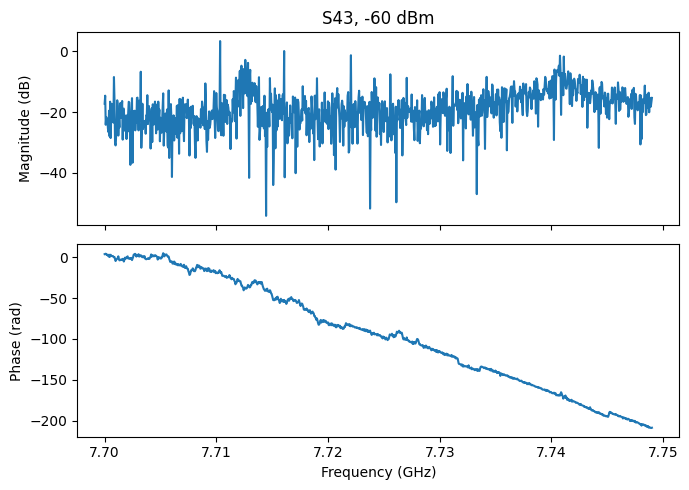

P=-60 dBm, IFBW=1e+06 Hz: fr=7.7106314 GHz, Q=2478, Q/w=0.05 us, dt~1.00 us


KeyboardInterrupt: 

In [16]:
ifbw_results = noise_study.scan_if_bandwidths(
    readout_powers_dbm=noise_branch_powers_dbm,
    if_bandwidths_hz=noise_if_bandwidths_hz,
    base_config=noise_base_config,
    points_per_segment=noise_sweep_points,
    avg_time_s=noise_sweep_avg_time_s,
    live_plot=True,
)
noise_study.plot_if_bandwidth_results(ifbw_results, readout_powers_dbm=noise_branch_powers_dbm)
noise_study.plot_if_bandwidth_fit_grid(
    ifbw_results,
    unit_mode=ifbw_fit_grid_unit_mode,
    fitres_adapter=noise_fit_adapter,
)

# One fit per power, chosen at the IFBW nearest timestream_if_bandwidths_hz[0].
# Used for optional circle overlays and resonator-basis conversion.
timestream_basis_fits = noise_study.fits_from_ifbw_results(
    ifbw_results,
    target_if_bw_hz=timestream_if_bandwidths_hz[0],
)


## Part 2: Ring-Up Time

The resonator timing estimate is `Q / (2*pi*fr)`. The practical check here is `ringup_s < sample_interval_s < noise_t1_s`, where `sample_interval_s` is approximated as `1 / IFBW`.


In [ ]:
for row in sorted(ifbw_results, key=lambda r: (r["readout_power_dbm"], r["if_bw_hz"])):
    status = "OK" if row["timing_ok"] else "check"
    print(
        f"{status:5s} P={row['readout_power_dbm']:>5.1f} dBm, "
        f"IFBW={row['if_bw_hz']:>9.0f} Hz, "
        f"Q/w={row['ringup_s']*1e6:>7.2f} us, "
        f"dt={row['sample_interval_s']*1e6:>7.2f} us, "
        f"T1={noise_t1_s*1e6:.2f} us"
    )


## Part 3: Fixed-Frequency Time-Stream Grid

This is the actual zero-span time-stream measurement. It does not fit powers or use power ranges. It measures one blob at each frequency in `timestream_center_freqs_ghz`, including the waste frequency `timestream_center_ghz`.


In [19]:
timestream_grid = noise_study.acquire_fixed_frequency_grid(
    center_ghz=timestream_center_freqs_ghz,
    readout_powers_dbm=timestream_readout_powers_dbm,
    if_bandwidths_hz=timestream_if_bandwidths_hz,
    n_samples=timestream_n_samples,
    n_repeats=timestream_n_repeats,
    save_path=timestream_path,
    measurement=timestream_measurement,
    phase_units=timestream_phase_units,
    avg_time_s=timestream_avg_time_s,
)


IFBW=100000 Hz, P=-60 dBm, f=7.742847810 GHz, repeat 1/1: blob radius=4.864e-02
IFBW=100000 Hz, P=-60 dBm, f=7.492800227 GHz, repeat 1/1: blob radius=5.713e-02
IFBW=100000 Hz, P=-55 dBm, f=7.742847810 GHz, repeat 1/1: blob radius=2.725e-02
IFBW=100000 Hz, P=-55 dBm, f=7.492800227 GHz, repeat 1/1: blob radius=3.054e-02
IFBW=100000 Hz, P=-50 dBm, f=7.742847810 GHz, repeat 1/1: blob radius=1.536e-02
IFBW=100000 Hz, P=-50 dBm, f=7.492800227 GHz, repeat 1/1: blob radius=1.714e-02
IFBW=100000 Hz, P=-45 dBm, f=7.742847810 GHz, repeat 1/1: blob radius=8.970e-03
IFBW=100000 Hz, P=-45 dBm, f=7.492800227 GHz, repeat 1/1: blob radius=9.676e-03
IFBW=300000 Hz, P=-60 dBm, f=7.742847810 GHz, repeat 1/1: blob radius=8.969e-02
IFBW=300000 Hz, P=-60 dBm, f=7.492800227 GHz, repeat 1/1: blob radius=1.171e-01
IFBW=300000 Hz, P=-55 dBm, f=7.742847810 GHz, repeat 1/1: blob radius=3.476e-02
IFBW=300000 Hz, P=-55 dBm, f=7.492800227 GHz, repeat 1/1: blob radius=3.966e-02
IFBW=300000 Hz, P=-50 dBm, f=7.742847810

## IQ Blob Grids

Each subplot is one readout power and IF bandwidth. Readout power is across columns; IF bandwidth is down rows. Each fixed-frequency sample is one point, and each repeated time stream contributes another cloud at the same setting. Blob colors indicate the zero-span frequency, with the legend shown on the upper-right subplot.


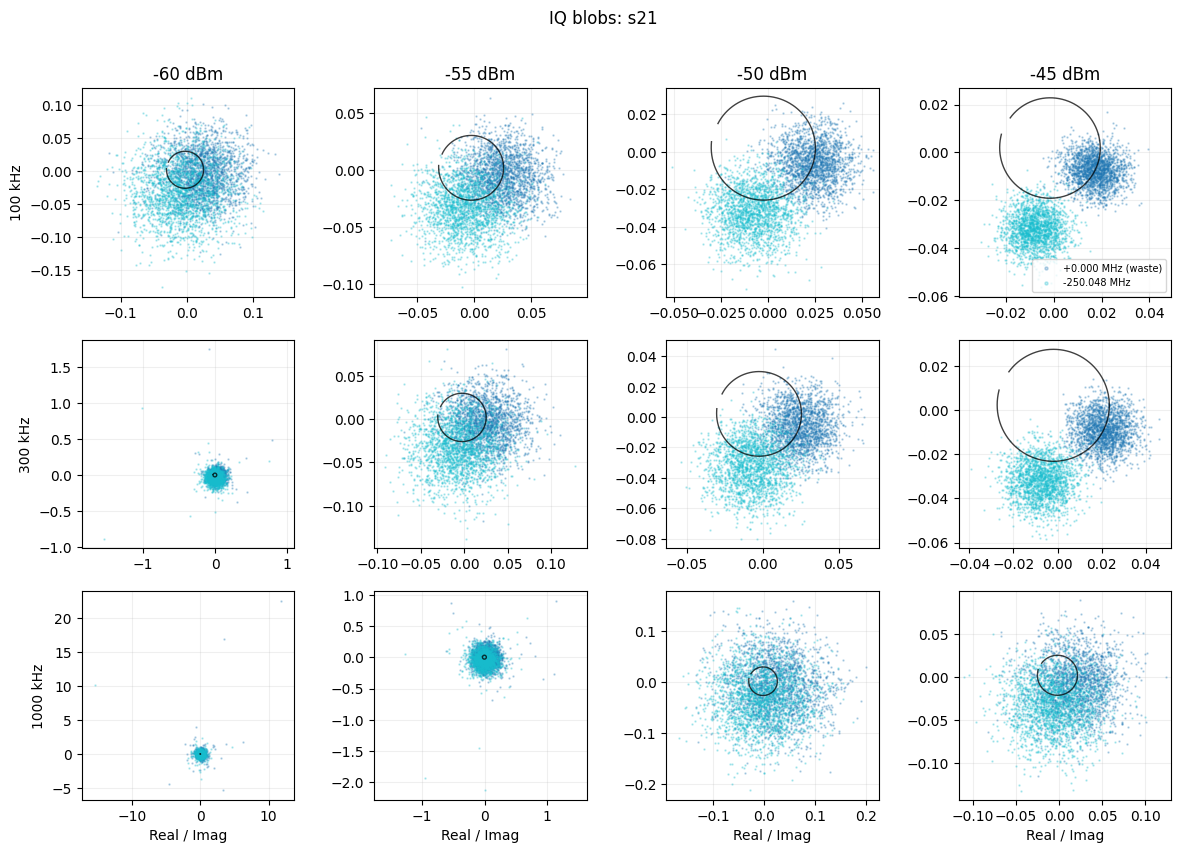

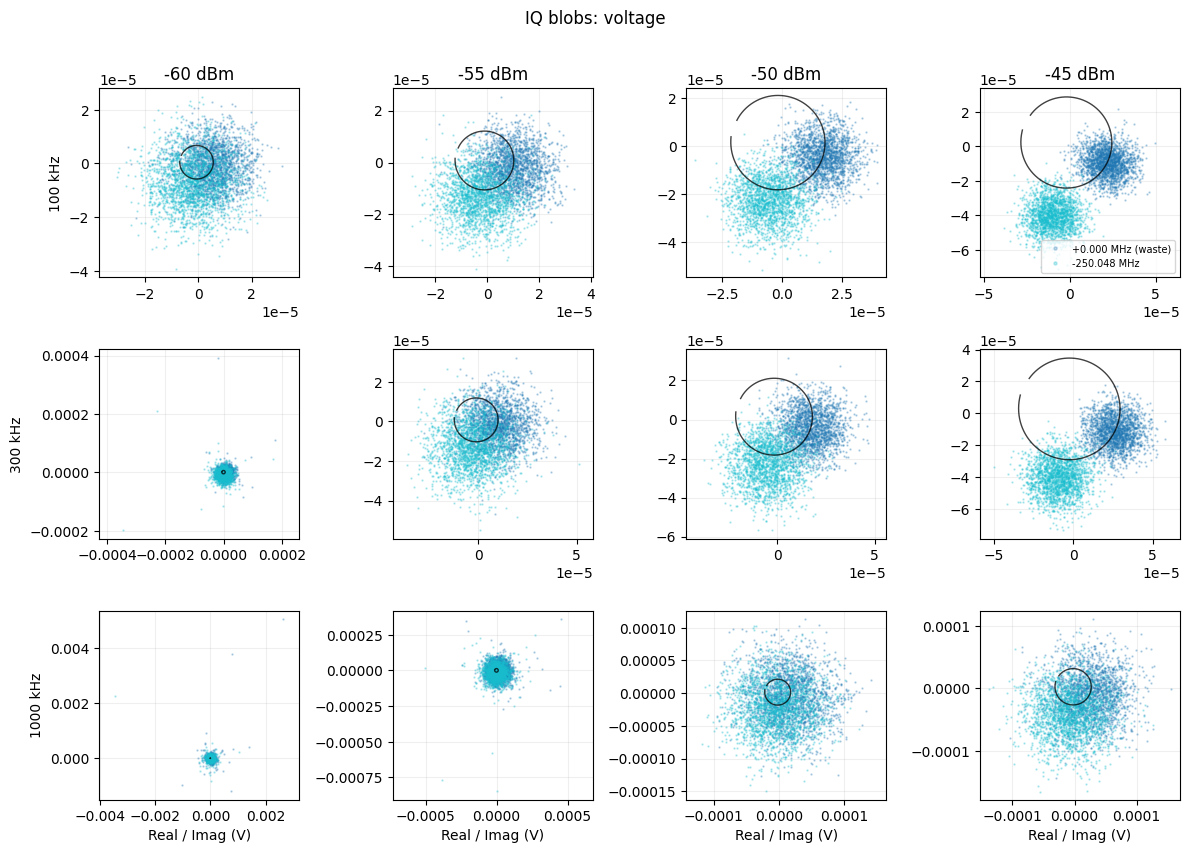

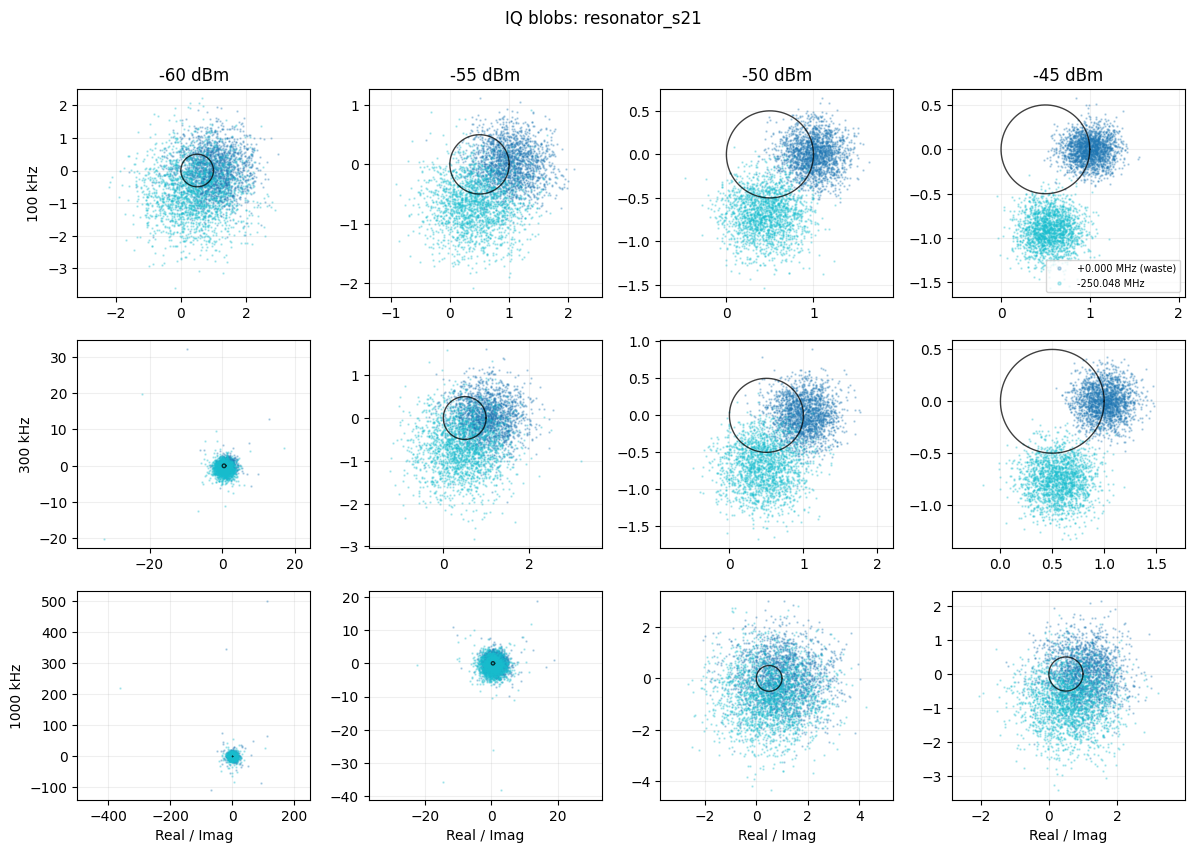

In [20]:
for unit_mode in timestream_unit_modes_to_plot:
    noise_study.plot_iq_grid(
        timestream_grid,
        unit_mode=unit_mode,
        power_fits=None if timestream_reference_fit is not None else timestream_basis_fits,
        reference_fit=timestream_reference_fit,
        fitres_adapter=noise_fit_adapter,
    )


## Timestream To PSD

PSDs are computed for each repeated time stream, then averaged across repeats at the same readout power and IF bandwidth. This averages PSD estimates, not the time streams themselves.


In [ ]:
for unit_mode in timestream_unit_modes_to_plot:
    noise_study.plot_psd_grid(
        timestream_grid,
        unit_mode=unit_mode,
        component=timestream_psd_component,
        power_fits=None if timestream_reference_fit is not None else timestream_basis_fits,
        reference_fit=timestream_reference_fit,
        fitres_adapter=noise_fit_adapter,
    )


## Big Picture

The old zero-span example is a time-stream measurement: fixed start and stop frequency, many points, one IQ point per sample. In this section, blob size can be viewed in raw S21 units, voltage units, or resonator-basis S21 units. If the blob is similar in S21 units while the fitted circle grows with readout power, the relative readout noise improves.


# Zoom In On Waste Resonance


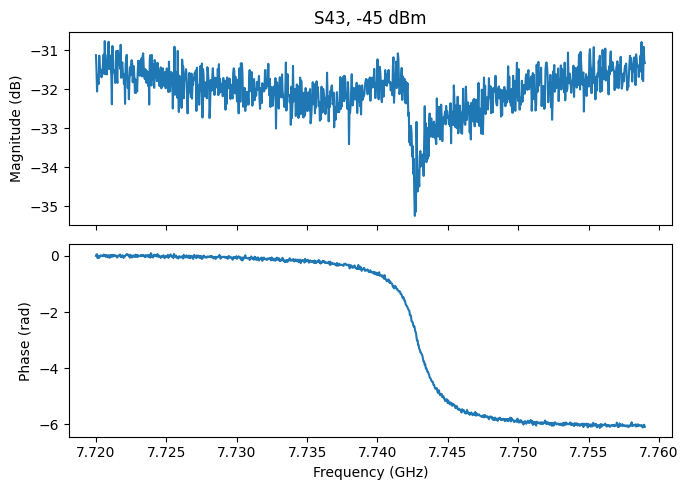

Waste resonance: 7.7428478 GHz


In [10]:
zoom_config = VNASweepConfig(
    start_ghz=7.72,
    stop_ghz=7.759,
    step_ghz=0.04,
    points_per_segment=1001,
    measurement="S43",
    rf_power_dbm=-45,
    if_bw_hz=10000,
    avg_time_s=10,
)
waste_initial_guess_ghz = 7.74

waste_sweep, waste_fit = waste_zoom.measure_and_fit(
    zoom_config,
    initial_guess_ghz=waste_initial_guess_ghz,
    save_path=WASTE_ZOOM_PATH,
    live_plot=True,
)
waste_resonance = waste_fit.fr_ghz
print(f"Waste resonance: {waste_resonance:.7f} GHz")


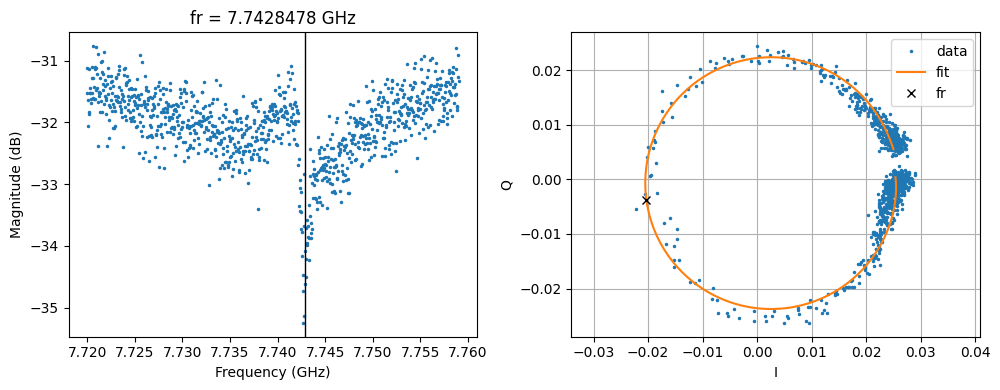

In [11]:
waste_zoom.plot_fit(waste_sweep, waste_fit)


# JPA Tuning

## Measure Waste Baseline


C:\_Data\SMPD\2026_05_29_JPA\waste_baseline_0529_run1.h5


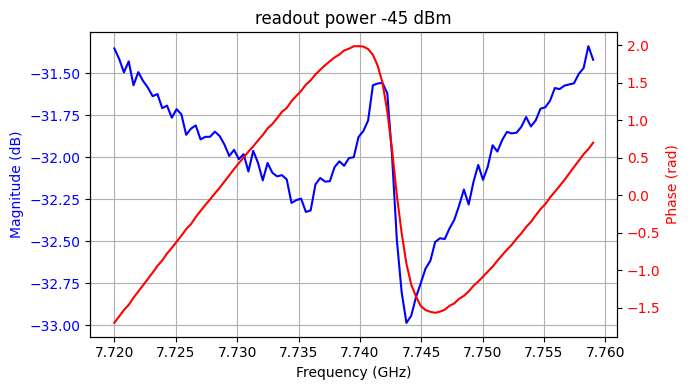

In [8]:
# Automatically put the JPA in the baseline/off state.
bias.set_voltage_mV(BASEL_CHANNEL, voltage_mv=JPA_OFF_BIAS_MV)
bias.enable_output(BASEL_CHANNEL)

if "SC" in globals():
    try:
        SC.close_device()
    except Exception:
        pass
SC = SignalCore(name="SC", address=SIGNALCORE_ADDRESS)
SC.set_output_state(enable=False)
SC.close_device()

set_name = WASTE_BASELINE_SET_NAME
file_name = WASTE_BASELINE_PATH

baseline_config = VNASweepConfig(
    start_ghz=7.72,
    stop_ghz=7.759,
    step_ghz=0.04,
    points_per_segment=101,
    measurement="S43",
    rf_power_dbm=-45,
    if_bw_hz=10000,
    avg_time_s=50,
    phase_fit_edge_fraction=10.0,
)

baseline_sweep = baseline_runner.measure(
    baseline_config,
    save_path=file_name,
    image_path=WASTE_BASELINE_IMAGE_PATH,
    live_plot=False,
)
print(file_name)


## Scan Pump Power And DC Bias


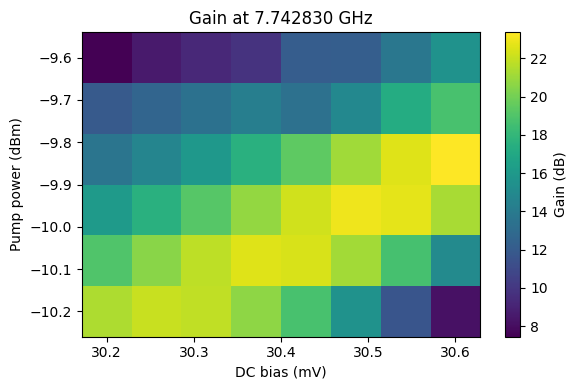

SC100026C4 : Set output state to False
C:\_Data\SMPD\2026_05_29_JPA\gain_data.h5


In [9]:
scan_powers_dbm = np.linspace(-10.2, -9.6, 6)
dc_biases = np.linspace(30.2, 30.6, 8)

scan_config = VNASweepConfig(
    start_ghz=7.72,
    stop_ghz=7.759,
    step_ghz=0.04,
    points_per_segment=101,
    measurement="S43",
    rf_power_dbm=-45,
    if_bw_hz=10000,
    avg_time_s=10,
)




if "baseline_sweep" not in globals():
    baseline_sweep = load_sweep_result(WASTE_BASELINE_PATH, config=scan_config)

# Automatically put the JPA in the on/scan state and keep SC open during the scan.
bias.set_voltage_mV(BASEL_CHANNEL, voltage_mv=JPA_ON_BIAS_MV)
bias.enable_output(BASEL_CHANNEL)

if "SC" in globals():
    try:
        SC.close_device()
    except Exception:
        pass
SC = SignalCore(name="SC", address=SIGNALCORE_ADDRESS)
SC.set_power(JPA_PUMP_POWER_DBM)
SC.set_output_state(enable=True)
SC.set_frequency(JPA_PUMP_FREQUENCY_HZ)

try:
    pump_bias_scan = PumpBiasScan(vna, SC, bias, BASEL_CHANNEL)
    scan_result = pump_bias_scan.scan(
        pump_powers_dbm=scan_powers_dbm,
        dc_biases_mv=dc_biases,
        sweep_config=scan_config,
        waste_resonance_ghz=waste_resonance,
        baseline=baseline_sweep,
        output_path=GAIN_SCAN_PATH,
        window_hz=0.5e6,
        live_heatmap=True,
    )
finally:
    SC.close_device()

print(GAIN_SCAN_PATH)


### Review Scan


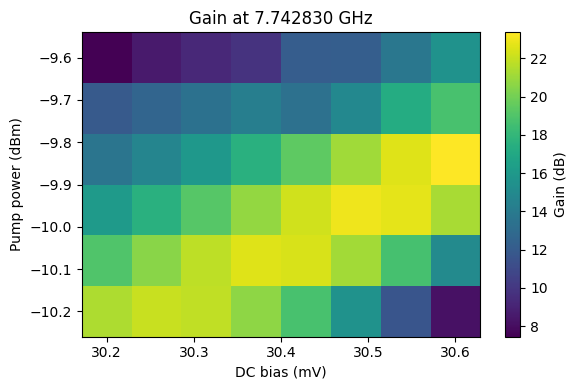

Maximum gain near resonance: 23.36 dB
Optimal pump power: -9.84 dBm
Optimal DC bias: 30.60 mV


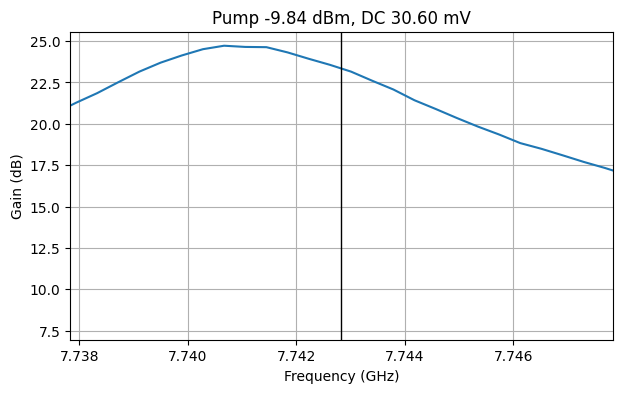

In [10]:
# Use this if you are reviewing a completed scan in a fresh kernel:
# scan_result = load_pump_bias_scan_result(GAIN_SCAN_PATH)
plot_gain_heatmap(scan_result, window_hz=0.5e6)

gain_at_res = scan_result.gain_at_resonance(window_hz=0.5e6)
max_idx = np.unravel_index(np.nanargmax(gain_at_res), gain_at_res.shape)
optimal_scan_power_dbm = scan_result.pump_powers_dbm[max_idx[0]]
optimal_dc_bias = scan_result.dc_biases_mv[max_idx[1]]

plt.figure(figsize=(7, 4))
plt.plot(scan_result.freq_ghz, scan_result.gain_db[max_idx[0], max_idx[1], :])
plt.axvline(scan_result.waste_resonance_ghz, color="k", lw=1)
plt.xlim(scan_result.waste_resonance_ghz - 0.005, scan_result.waste_resonance_ghz + 0.005)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Gain (dB)")
plt.title(f"Pump {optimal_scan_power_dbm:.2f} dBm, DC {optimal_dc_bias:.2f} mV")
plt.grid(True)

print(f"Maximum gain near resonance: {gain_at_res[max_idx]:.2f} dB")
print(f"Optimal pump power: {optimal_scan_power_dbm:.2f} dBm")
print(f"Optimal DC bias: {optimal_dc_bias:.2f} mV")
